# Lab 14 — Clasificador de gestos de la mano

**Integrantes:** Matias Carcamo e Israel Gonzalez

**Clases elegidas:** `ok`, `stop`, `paz`, `pulgar_arriba` y `otros`.

**Por qué:** son gestos comunes y fáciles de fotografiar con el celular, pero algunos se parecen entre sí
(por ejemplo, `stop` y `ok` muestran varios dedos estirados), así que el modelo tiene que fijarse en detalles de la mano.

**Criterio de etiquetado:**

| Clase | Qué muestra la foto |
| --- | --- |
| `ok` | Pulgar e índice forman un círculo y los otros tres dedos quedan estirados. |
| `stop` | Mano abierta con la palma hacia la cámara y los cinco dedos estirados. |
| `paz` | Índice y medio estirados en forma de V; los demás dedos, doblados. |
| `pulgar_arriba` | Puño cerrado con el pulgar estirado (hacia arriba o un poco inclinado). |
| `otros` | Cualquier otro gesto: corazón con las manos, puño, etc. |

Si en una foto no se distingue el gesto, no se usa.

## Qué hace este notebook

1. Carga las fotos de `data/train` y `data/test` con `ImageFolder`.
2. Aplica *data augmentation* solo a las fotos de entrenamiento.
3. Toma una **ResNet-18 preentrenada** en ImageNet y cambia su última capa para nuestras 5 clases (*fine-tuning*).
4. Entrena con `data/train`.
5. Evalúa **una sola vez** con `data/test`: exactitud y matriz de confusión.

Las fotos ya fueron separadas y reducidas a 512 px por `preparar_datos.py`.

## 1. Librerías y configuración

Importamos lo necesario y fijamos una semilla para que el resultado se pueda repetir.

In [1]:
import json
import random
import time
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import torch
from torch import nn
from torch.utils.data import DataLoader
from torchmetrics.classification import MulticlassConfusionMatrix
from torchvision import datasets, models, transforms
from torchvision.transforms import functional as F

SEED = 0
random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
if device.type == "cuda":
    probe = torch.ones(2, 2, device=device) @ torch.ones(2, 2, device=device)
    torch.cuda.synchronize()
    assert probe.is_cuda and torch.isfinite(probe).all().item()
    print(f"GPU verificada: {torch.cuda.get_device_name(0)} | CUDA {torch.version.cuda}")
else:
    warnings.warn("CUDA no disponible: se entrenara y evaluara en CPU.")

IMAGE_SIZE = 320
BATCH_SIZE = 16
EPOCHS = 10
LEARNING_RATE = 1e-4
RESULTS_DIR = Path("resultados")
RESULTS_DIR.mkdir(exist_ok=True)

print(f"PyTorch {torch.__version__} | dispositivo: {device}")

GPU verificada: NVIDIA GeForce RTX 4050 Laptop GPU | CUDA 13.0
PyTorch 2.14.1+cu130 | dispositivo: cuda


## 2. Transformaciones de las imágenes

Antes de entrar a la red, cada foto:

* se rellena con negro hasta quedar **cuadrada**, para no deformarla ni cortar la mano;
* se reduce a `IMAGE_SIZE × IMAGE_SIZE`;
* se convierte a tensor y se **normaliza** con la media y desviación de ImageNet (lo que espera la red preentrenada).

**Data augmentation (solo en train):** pequeñas rotaciones, desplazamientos, zoom, espejo horizontal y cambios de brillo/contraste.
Así el modelo ve variantes distintas de cada foto en cada época. En test no se usa: queremos evaluar las fotos tal como son.

In [2]:
class PadToSquare:
    """Rellena los bordes para que la foto quede cuadrada sin deformarla."""

    def __call__(self, image):
        width, height = image.size
        side = max(width, height)
        left = (side - width) // 2
        top = (side - height) // 2
        return F.pad(image, [left, top, side - width - left, side - height - top], fill=0)


IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    PadToSquare(),
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomAffine(degrees=10, translate=(0.05, 0.05), scale=(0.9, 1.1)),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

test_transform = transforms.Compose([
    PadToSquare(),
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

## 3. Cargar los datos

`ImageFolder` usa el **nombre de cada carpeta como etiqueta**: todo lo que está en `data/train/paz/` es de la clase `paz`.
El `DataLoader` entrega las fotos por lotes; en train se barajan en cada época.

In [3]:
train_data = datasets.ImageFolder("data/train", transform=train_transform)
test_data = datasets.ImageFolder("data/test", transform=test_transform)

CLASS_NAMES = train_data.classes
assert CLASS_NAMES == test_data.classes, "train y test deben tener las mismas carpetas"

train_loader = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_data, batch_size=BATCH_SIZE)

print(f"{'clase':<15}{'train':>7}{'test':>7}")
for index, name in enumerate(CLASS_NAMES):
    n_train = train_data.targets.count(index)
    n_test = test_data.targets.count(index)
    print(f"{name:<15}{n_train:>7}{n_test:>7}")
print(f"{'total':<15}{len(train_data):>7}{len(test_data):>7}")

clase            train   test
ok                  55     14
otros               59     15
paz                140     36
pulgar_arriba       76     19
stop               110     27
total              440    111


## 4. Ver algunas fotos de entrenamiento

Así llegan las fotos a la red, ya con el *data augmentation* aplicado.
Para mostrarlas hay que deshacer la normalización.

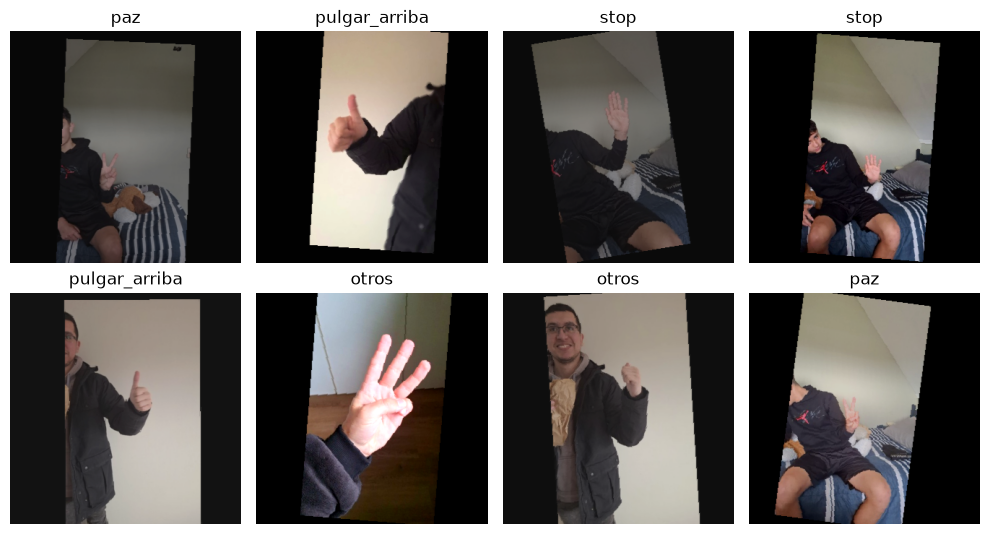

In [4]:
def to_displayable(image):
    """Deshace la normalización para poder mostrar la imagen."""
    mean = torch.tensor(IMAGENET_MEAN).view(3, 1, 1)
    std = torch.tensor(IMAGENET_STD).view(3, 1, 1)
    return (image * std + mean).clamp(0, 1).permute(1, 2, 0)


images, labels = next(iter(train_loader))

figure, axes = plt.subplots(nrows=2, ncols=4, figsize=(10, 5.5))
for axis, image, label in zip(axes.flatten(), images, labels):
    axis.imshow(to_displayable(image))
    axis.set_title(CLASS_NAMES[label])
    axis.axis("off")
plt.tight_layout()
plt.show()

## 5. El modelo: ResNet-18 preentrenada

La ResNet-18 viene de `torchvision` con pesos entrenados en **ImageNet** (1,2 millones de fotos de 1.000 categorías).
Ya sabe detectar bordes, formas y texturas; solo le falta aprender nuestros gestos.

Cambiamos su última capa (`fc`), que tenía 1.000 salidas, por una con **5 salidas**, una por gesto.

In [5]:
model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
model.fc = nn.Linear(model.fc.in_features, len(CLASS_NAMES))
model = model.to(device)

total_parameters = sum(parameter.numel() for parameter in model.parameters())
print(f"última capa: {model.fc}")
print(f"parámetros: {total_parameters:,}")

última capa: Linear(in_features=512, out_features=5, bias=True)
parámetros: 11,179,077


## 6. Entrenamiento (*fine-tuning*)

Es el mismo ciclo de `entrenamiento_mnist.ipynb`: predecir, calcular la pérdida, borrar gradientes, retropropagar y actualizar.
Se ajustan todos los pesos de la red, con una tasa de aprendizaje baja para no destruir lo que ya sabía.

In [6]:
def train(model, loader, epochs, learning_rate):
    optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate)
    loss_function = nn.CrossEntropyLoss()
    history = []

    for epoch in range(epochs):
        model.train()
        total_loss, correct = 0.0, 0

        for x, y in loader:
            x, y = x.to(device), y.to(device)

            predictions = model(x)
            loss = loss_function(predictions, y)
            if not torch.isfinite(loss).item():
                raise RuntimeError(f"Perdida no finita en la epoca {epoch + 1}")

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            total_loss += loss.item() * len(x)
            correct += (predictions.argmax(dim=1) == y).sum().item()

        n = len(loader.dataset)
        history.append({"epoca": epoch + 1, "perdida": total_loss / n, "exactitud": correct / n})
        print(f"época {epoch + 1:>2}/{epochs} | pérdida {total_loss / n:.4f} | exactitud train {correct / n:.3f}")
    return history

In [7]:
training_started = time.perf_counter()
train_history = train(model, train_loader, EPOCHS, LEARNING_RATE)
if device.type == "cuda":
    torch.cuda.synchronize()
training_seconds = time.perf_counter() - training_started
print(f"Tiempo de entrenamiento: {training_seconds:.1f} s")

época  1/10 | pérdida 1.0520 | exactitud train 0.616


época  2/10 | pérdida 0.4120 | exactitud train 0.895


época  3/10 | pérdida 0.1921 | exactitud train 0.950


época  4/10 | pérdida 0.1331 | exactitud train 0.973


época  5/10 | pérdida 0.0879 | exactitud train 0.982


época  6/10 | pérdida 0.0683 | exactitud train 0.989


época  7/10 | pérdida 0.0661 | exactitud train 0.984


época  8/10 | pérdida 0.0787 | exactitud train 0.984


época  9/10 | pérdida 0.0610 | exactitud train 0.980


época 10/10 | pérdida 0.0648 | exactitud train 0.984
Tiempo de entrenamiento: 65.1 s


## 7. Evaluación en `data/test`

Ahora usamos las fotos que el modelo **nunca vio** al entrenar.
La exactitud es la fracción de fotos de test que clasifica bien (la meta del lab es ≥ 0,80).

In [8]:
@torch.no_grad()
def predict(model, loader):
    model.eval()
    all_predictions, all_labels = [], []
    for x, y in loader:
        all_predictions.append(model(x.to(device)).argmax(dim=1).cpu())
        all_labels.append(y)
    return torch.cat(all_predictions), torch.cat(all_labels)


test_predictions, test_labels = predict(model, test_loader)
test_accuracy = (test_predictions == test_labels).float().mean().item()

print(f"exactitud en test: {test_accuracy:.4f}  ({(test_predictions == test_labels).sum()}/{len(test_labels)} fotos)")

exactitud en test: 0.8468  (94/111 fotos)


## 8. Matriz de confusión

Cada fila es la clase **real** y cada columna la clase **predicha**.
La diagonal son los aciertos; lo que queda fuera de ella muestra qué gestos confunde el modelo.

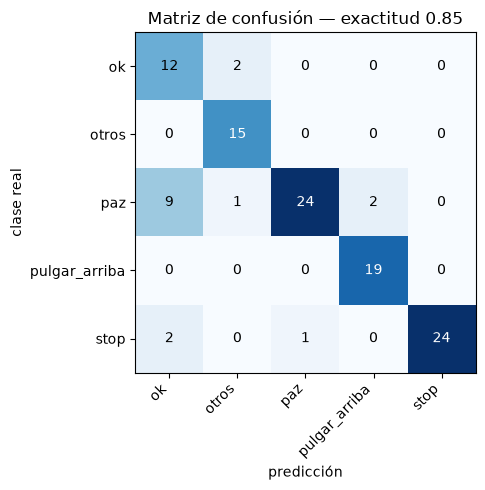

In [9]:
confusion = MulticlassConfusionMatrix(num_classes=len(CLASS_NAMES))(test_predictions, test_labels)

figure, axis = plt.subplots(figsize=(6, 5))
axis.imshow(confusion, cmap="Blues")
axis.set_xticks(range(len(CLASS_NAMES)), CLASS_NAMES, rotation=45, ha="right")
axis.set_yticks(range(len(CLASS_NAMES)), CLASS_NAMES)
axis.set_xlabel("predicción")
axis.set_ylabel("clase real")
axis.set_title(f"Matriz de confusión — exactitud {test_accuracy:.2f}")

for row in range(len(CLASS_NAMES)):
    for column in range(len(CLASS_NAMES)):
        value = confusion[row, column].item()
        color = "white" if value > confusion.max() / 2 else "black"
        axis.text(column, row, value, ha="center", va="center", color=color)

plt.tight_layout()
plt.show()

## 9. Ver predicciones en fotos de test

Verde si acertó, rojo si se equivocó.

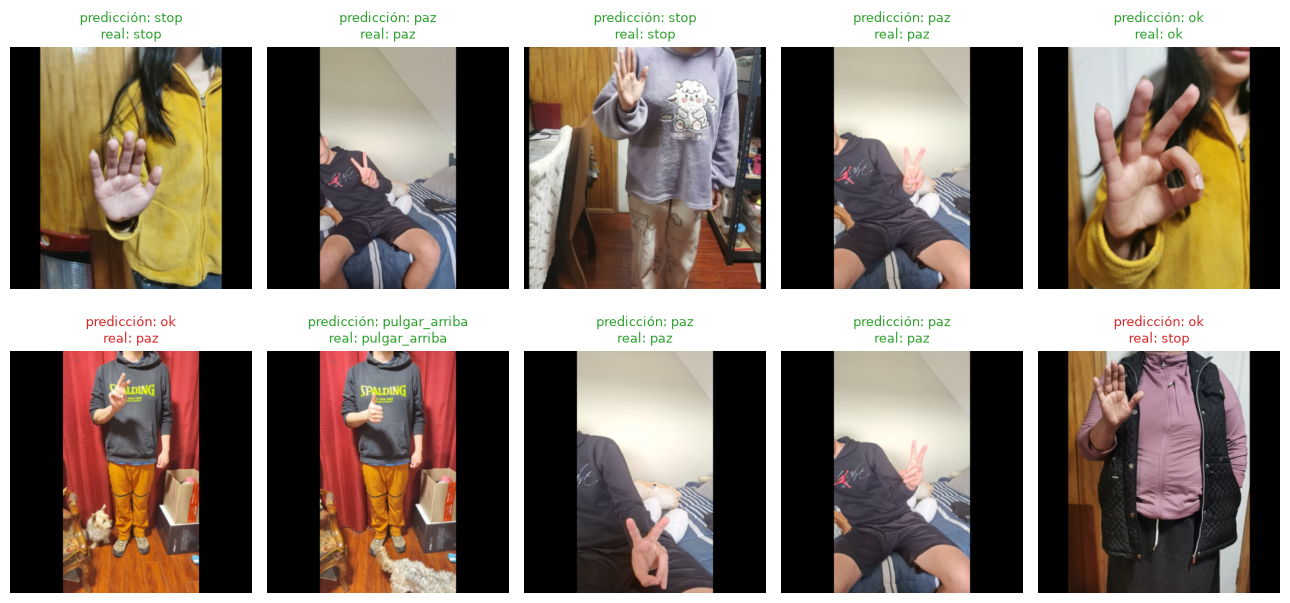

In [10]:
sample = random.Random(SEED).sample(range(len(test_data)), 10)

figure, axes = plt.subplots(nrows=2, ncols=5, figsize=(13, 6.5))
for axis, index in zip(axes.flatten(), sample):
    image, label = test_data[index]
    prediction = test_predictions[index].item()
    axis.imshow(to_displayable(image))
    axis.set_title(
        f"predicción: {CLASS_NAMES[prediction]}\nreal: {CLASS_NAMES[label]}",
        color="tab:green" if prediction == label else "tab:red",
        fontsize=9,
    )
    axis.axis("off")
plt.tight_layout()
plt.show()

## 10. Resumen

In [11]:
summary = {
    "modelo": "ResNet-18 preentrenada (ImageNet), fine-tuning completo",
    "clases": ", ".join(CLASS_NAMES),
    "fotos train / test": f"{len(train_data)} / {len(test_data)}",
    "tamaño de imagen": f"{IMAGE_SIZE} x {IMAGE_SIZE}",
    "optimizador": "AdamW",
    "learning_rate": LEARNING_RATE,
    "batch_size": BATCH_SIZE,
    "épocas": EPOCHS,
    "exactitud test": round(test_accuracy, 4),
    "dispositivo": str(device),
    "gpu": torch.cuda.get_device_name(0) if device.type == "cuda" else None,
    "pytorch": str(torch.__version__),
    "cuda": torch.version.cuda,
    "precision mixta": False,
    "segundos entrenamiento": round(training_seconds, 2),
}

for key, value in summary.items():
    print(f"{key:<20} {value}")

torch.save({
    "state_dict": {key: value.cpu() for key, value in model.state_dict().items()},
    "class_names": CLASS_NAMES,
    "image_size": IMAGE_SIZE,
    "imagenet_mean": IMAGENET_MEAN,
    "imagenet_std": IMAGENET_STD,
    "summary": summary,
}, RESULTS_DIR / "gestos_resnet18.pt")
report = {
    "resumen": summary,
    "historial_train": train_history,
    "clases": CLASS_NAMES,
    "matriz_confusion": confusion.tolist(),
    "predicciones_test": [
        {"archivo": path, "real": CLASS_NAMES[label], "prediccion": CLASS_NAMES[prediction]}
        for (path, label), prediction in zip(test_data.samples, test_predictions.tolist())
    ],
}
with (RESULTS_DIR / "evaluacion.json").open("w", encoding="utf-8") as file:
    json.dump(report, file, ensure_ascii=False, indent=2)
print(f"Modelo y evaluacion guardados en {RESULTS_DIR.resolve()}")

modelo               ResNet-18 preentrenada (ImageNet), fine-tuning completo
clases               ok, otros, paz, pulgar_arriba, stop
fotos train / test   440 / 111
tamaño de imagen     320 x 320
optimizador          AdamW
learning_rate        0.0001
batch_size           16
épocas               10
exactitud test       0.8468
dispositivo          cuda
gpu                  NVIDIA GeForce RTX 4050 Laptop GPU
pytorch              2.14.1+cu130
cuda                 13.0
precision mixta      False
segundos entrenamiento 65.12
Modelo y evaluacion guardados en C:\src\Segundo Semestre\IA\25_lab_14\resultados
